# Creative fatigue — survival analysis

A first-pass pipeline for the Smadex dataset using the framing we landed on: each creative is a subject, `fatigue_day` is the event time for those who fatigue, everyone else is right-censored. We'll do Kaplan–Meier first (the shape of survival), then Cox proportional hazards (which creative features drive the hazard), then check assumptions, then compute a residual-risk score for still-running creatives.

**What we are *not* doing here:** predicting status from post-hoc features (CTR decay, perf_score, etc.). Those columns leak the outcome. Survival analysis uses only information you'd have *before* or *at* launch — creative metadata + targeting.

**Libraries:** `lifelines` for KM/Cox, pandas for wrangling, matplotlib for plots.

In [9]:
# If lifelines is not installed, uncomment the next line once:
# pip install lifelines
            
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
np.random.seed(42)

## 1. Load and frame the survival problem

The event/duration/censoring decision is the single most important step — mess this up and everything downstream is noise.

| Status | Event (1) / Censored (0) | Duration |
|---|---|---|
| `fatigued` | 1 | `fatigue_day` (10–17) |
| `stable` | 0 | `total_days_active` |
| `top_performer` | 0 | `total_days_active` |
| `underperformer` | 0 | `total_days_active` |

Underperformers are censored, not events. They never crossed the fatigue threshold because they started low — that's a different failure mode (born bad vs. decaying), and folding them into events would pool two hazards into one.

In [11]:
DATA = "../data"  # change if your files live elsewhere

crs = pd.read_csv(f"{DATA}/creative_summary.csv")
camp = pd.read_csv(f"{DATA}/campaigns.csv")

# Build the survival frame
surv = crs.copy()
surv["event"] = (surv["creative_status"] == "fatigued").astype(int)
surv["duration"] = np.where(
    surv["event"] == 1,
    surv["fatigue_day"],
    surv["total_days_active"],
).astype(float)

# Sanity: no duration of 0 (would mean fatigue on launch day, which doesn't exist here)
assert (surv["duration"] > 0).all(), "Zero-duration rows found"

print(f"n = {len(surv)}")
print(f"events (fatigued): {surv['event'].sum()} ({surv['event'].mean()*100:.1f}%)")
print(f"censored: {(1-surv['event']).sum()}")
print(f"\nduration summary:")
print(surv["duration"].describe().round(1).to_string())

n = 1080
events (fatigued): 199 (18.4%)
censored: 881

duration summary:
count    1080.0
mean       41.8
std        16.4
min        10.0
25%        36.0
50%        45.0
75%        54.0
max        74.0


## 2. Kaplan–Meier: the overall survival curve

One line, all 1,080 creatives. This is our *baseline*: the probability of still being non-fatigued at each day since launch.

**What to look for:** a near-flat stretch from day 0 to day ~9, then a cliff between days 10–17 (that's where all the fatigue events live), then a long flat tail because ~82% of creatives never fatigue. The median survival time will never be reached — we'll report the 10th and 25th percentiles instead.

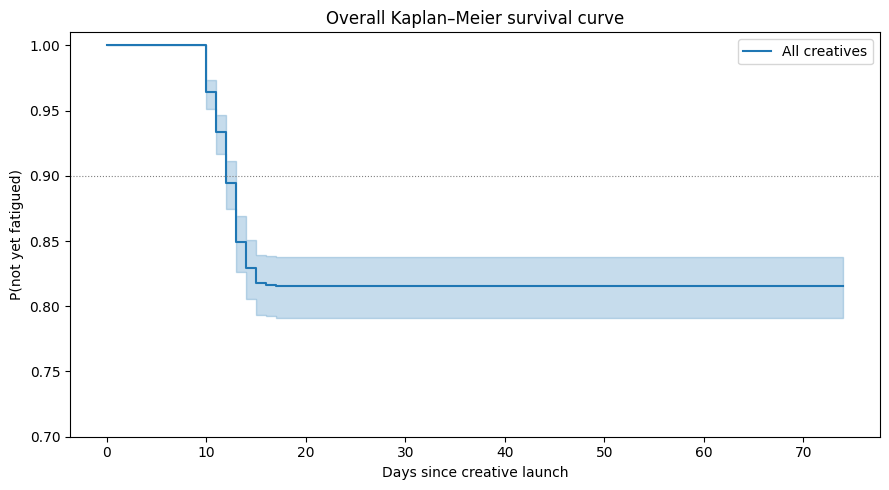

Day by which X% of creatives have fatigued:
    5% fatigued → day 11.0
   10% fatigued → day 12.0
   15% fatigued → day 13.0
   20% fatigued → day inf


c:\Users\Miki\anaconda3\Lib\site-packages\lifelines\fitters\__init__.py:279: ApproximationWarning: Approximating using `survival_function_`. To increase accuracy, try using or increasing the resolution of the timeline kwarg in `.fit(..., timeline=timeline)`.

  warnings.warn(
c:\Users\Miki\anaconda3\Lib\site-packages\lifelines\fitters\__init__.py:279: ApproximationWarning: Approximating using `survival_function_`. To increase accuracy, try using or increasing the resolution of the timeline kwarg in `.fit(..., timeline=timeline)`.

  warnings.warn(
c:\Users\Miki\anaconda3\Lib\site-packages\lifelines\fitters\__init__.py:279: ApproximationWarning: Approximating using `survival_function_`. To increase accuracy, try using or increasing the resolution of the timeline kwarg in `.fit(..., timeline=timeline)`.

  warnings.warn(
c:\Users\Miki\anaconda3\Lib\site-packages\lifelines\fitters\__init__.py:279: ApproximationWarning: Approximating using `survival_function_`. To increase accuracy, try us

In [12]:
kmf = KaplanMeierFitter()
kmf.fit(surv["duration"], surv["event"], label="All creatives")

fig, ax = plt.subplots(figsize=(9, 5))
kmf.plot_survival_function(ax=ax, ci_show=True)
ax.set_xlabel("Days since creative launch")
ax.set_ylabel("P(not yet fatigued)")
ax.set_title("Overall Kaplan–Meier survival curve")
ax.axhline(0.9, color="gray", linestyle=":", linewidth=0.8)
ax.set_ylim(0.7, 1.01)
plt.tight_layout()
plt.show()

# Report percentiles of survival time (when does X% of the cohort fatigue by?)
print("Day by which X% of creatives have fatigued:")
for pct in [0.05, 0.10, 0.15, 0.20]:
    day = kmf.percentile(1 - pct)
    print(f"  {int(pct*100):>3}% fatigued → day {day}")

## 3. Kaplan–Meier stratified by format

Five strata: banner, native, interstitial, rewarded_video, playable. The log-rank test asks whether the curves are identical in the population; a small p-value means format genuinely affects fatigue timing.

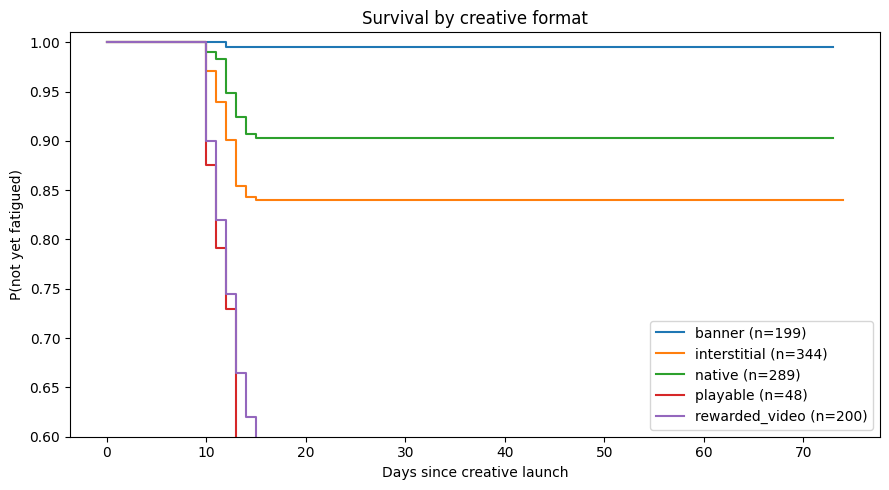

Log-rank test across formats:  χ² = 210.8,  p = 1.828e-44


In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

for fmt in sorted(surv["format"].unique()):
    mask = surv["format"] == fmt
    if mask.sum() < 10:
        continue
    KaplanMeierFitter().fit(
        surv.loc[mask, "duration"],
        surv.loc[mask, "event"],
        label=f"{fmt} (n={mask.sum()})",
    ).plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel("Days since creative launch")
ax.set_ylabel("P(not yet fatigued)")
ax.set_title("Survival by creative format")
ax.set_ylim(0.6, 1.01)
plt.tight_layout()
plt.show()

# Multivariate log-rank across all formats
lr = multivariate_logrank_test(surv["duration"], surv["format"], surv["event"])
print(f"Log-rank test across formats:  χ² = {lr.test_statistic:.1f},  p = {lr.p_value:.4g}")

## 4. Kaplan–Meier stratified by vertical

Same idea, different axis. Our prior from the EDA: gaming should fatigue fastest (highest launch CTR, most novelty-dependent), fintech/travel should fatigue slowest.

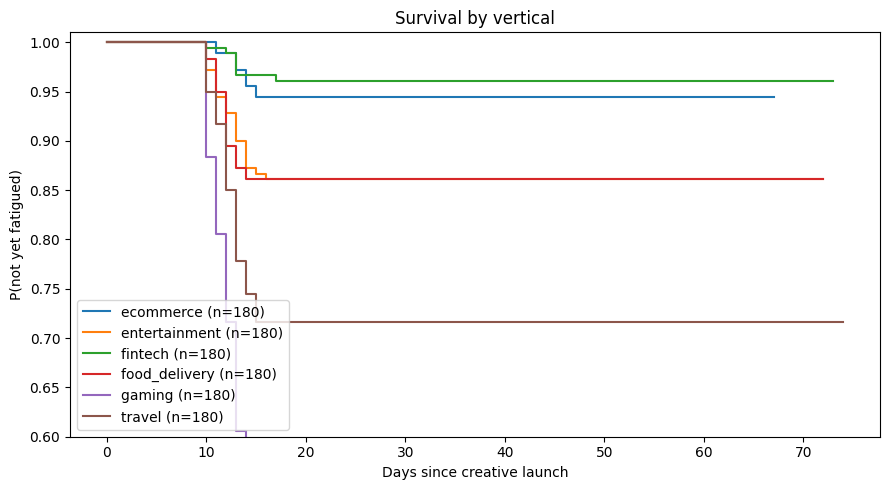

Log-rank test across verticals:  χ² = 161.2,  p = 5.583e-33


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

for v in sorted(surv["vertical"].unique()):
    mask = surv["vertical"] == v
    KaplanMeierFitter().fit(
        surv.loc[mask, "duration"],
        surv.loc[mask, "event"],
        label=f"{v} (n={mask.sum()})",
    ).plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel("Days since creative launch")
ax.set_ylabel("P(not yet fatigued)")
ax.set_title("Survival by vertical")
ax.set_ylim(0.6, 1.01)
plt.tight_layout()
plt.show()

lr = multivariate_logrank_test(surv["duration"], surv["vertical"], surv["event"])
print(f"Log-rank test across verticals:  χ² = {lr.test_statistic:.1f},  p = {lr.p_value:.4g}")

## 5. Binary feature: has_gameplay

From the EDA, this was the single biggest binary separator between top performers and underperformers (+444%). If it matters for fatigue too, it's a strong pre-launch lever.

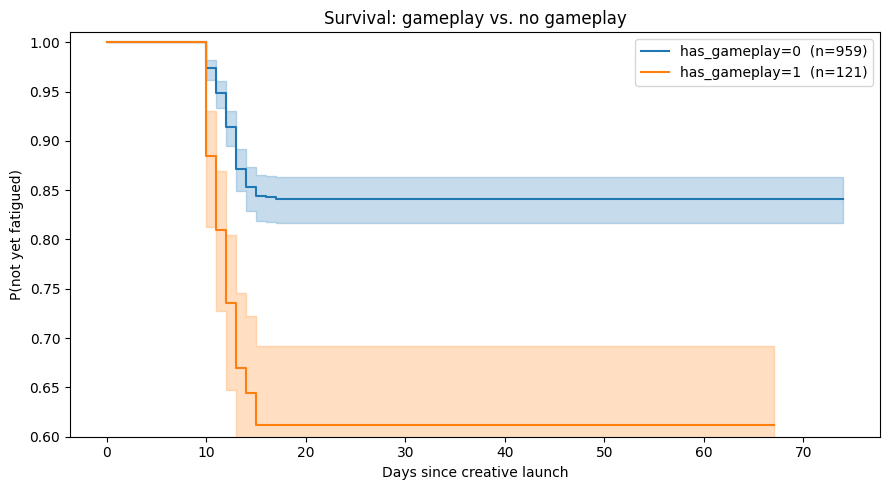

Log-rank test gameplay 0 vs 1:  χ² = 44.57,  p = 2.454e-11


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

for val in [0, 1]:
    mask = surv["has_gameplay"] == val
    label = f"has_gameplay={val}  (n={mask.sum()})"
    KaplanMeierFitter().fit(
        surv.loc[mask, "duration"],
        surv.loc[mask, "event"],
        label=label,
    ).plot_survival_function(ax=ax, ci_show=True)

ax.set_xlabel("Days since creative launch")
ax.set_ylabel("P(not yet fatigued)")
ax.set_title("Survival: gameplay vs. no gameplay")
ax.set_ylim(0.6, 1.01)
plt.tight_layout()
plt.show()

g0 = surv[surv["has_gameplay"] == 0]
g1 = surv[surv["has_gameplay"] == 1]
lr = logrank_test(g0["duration"], g1["duration"], g0["event"], g1["event"])
print(f"Log-rank test gameplay 0 vs 1:  χ² = {lr.test_statistic:.2f},  p = {lr.p_value:.4g}")

## 6. Cox proportional hazards — feature selection

KM tells us *whether* groups differ; Cox tells us *by how much*, controlling for everything else. The output is a set of hazard ratios (HR): HR > 1 means faster fatigue, HR < 1 means protection.

**Feature inclusion policy:**
- *Structural controls*: vertical, format, target_os (so creative-feature HRs are estimated *within* comparable groups).
- *Creative-design features*: novelty, motion, clutter, brand visibility, text density, faces, products, gameplay, UGC style, discount badge, price, duration.
- **Hard-excluded (leakage)**: any column computed from the outcome — `overall_ctr`, `overall_cvr`, `ctr_decay_pct`, `last_7d_*`, `peak_rolling_ctr_5`, `perf_score`, `total_*`, `creative_status`, `fatigue_day`.

Before fitting, also drop near-zero-variance columns and handle categoricals with dummy variables (Cox needs numeric input).

In [16]:
structural = ["vertical", "format"]  # categorical — will be dummy-encoded
creative_num = [
    "text_density", "readability_score", "brand_visibility_score",
    "clutter_score", "novelty_score", "motion_score",
    "faces_count", "product_count", "duration_sec", "copy_length_chars",
]
creative_bin = ["has_price", "has_discount_badge", "has_gameplay", "has_ugc_style"]

feature_cols = structural + creative_num + creative_bin
cox_df = surv[feature_cols + ["duration", "event"]].copy()

# Dummy-encode categoricals (drop_first to avoid the dummy-variable trap)
cox_df = pd.get_dummies(cox_df, columns=structural, drop_first=True, dtype=float)

# Drop any rows with nulls (there shouldn't be any, but be safe)
before = len(cox_df)
cox_df = cox_df.dropna()
print(f"Rows kept after dropna: {len(cox_df)} / {before}")
print(f"Features entering Cox: {cox_df.shape[1] - 2}")

Rows kept after dropna: 1080 / 1080
Features entering Cox: 23


## 7. Fit the Cox model and read the hazard ratios

`penalizer=0.01` is a tiny L2 ridge to keep the model well-conditioned when dummies are correlated with each other. Without it, a `vertical_gaming` HR can swing wildly if it partly overlaps with `format_playable`.

In [17]:
cph = CoxPHFitter(penalizer=0.01)
cph.fit(cox_df, duration_col="duration", event_col="event")

summary = cph.summary[["coef", "exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
summary = summary.rename(columns={
    "exp(coef)": "HR",
    "exp(coef) lower 95%": "HR_lo",
    "exp(coef) upper 95%": "HR_hi",
})
summary = summary.sort_values("HR")
print(summary.round(3).to_string())

print(f"\nConcordance index: {cph.concordance_index_:.3f}")
print("(0.5 = random, 1.0 = perfect; >0.7 is a useful model for survival)")

                         coef     HR  HR_lo   HR_hi      p
covariate                                                 
text_density           -0.594  0.552  0.247   1.235  0.148
clutter_score          -0.536  0.585  0.209   1.641  0.309
vertical_fintech       -0.416  0.659  0.291   1.492  0.318
has_ugc_style          -0.122  0.885  0.645   1.214  0.449
faces_count            -0.122  0.885  0.764   1.025  0.103
product_count          -0.108  0.897  0.762   1.056  0.191
has_gameplay           -0.098  0.907  0.597   1.378  0.646
has_price              -0.020  0.980  0.683   1.407  0.914
copy_length_chars      -0.001  0.999  0.991   1.007  0.760
duration_sec            0.021  1.021  1.000   1.043  0.052
vertical_entertainment  0.303  1.355  0.683   2.684  0.385
novelty_score           0.391  1.479  0.696   3.140  0.309
brand_visibility_score  0.404  1.497  0.623   3.600  0.367
has_discount_badge      0.584  1.793  1.291   2.491  0.000
vertical_travel         0.721  2.056  1.192   3.545  0.0

### Plot the hazard ratios

A forest plot is the standard way to read a Cox model. HRs are on a log scale so "halves the hazard" and "doubles the hazard" look symmetric. The vertical line at HR=1 is "no effect"; confidence intervals crossing that line are non-significant.

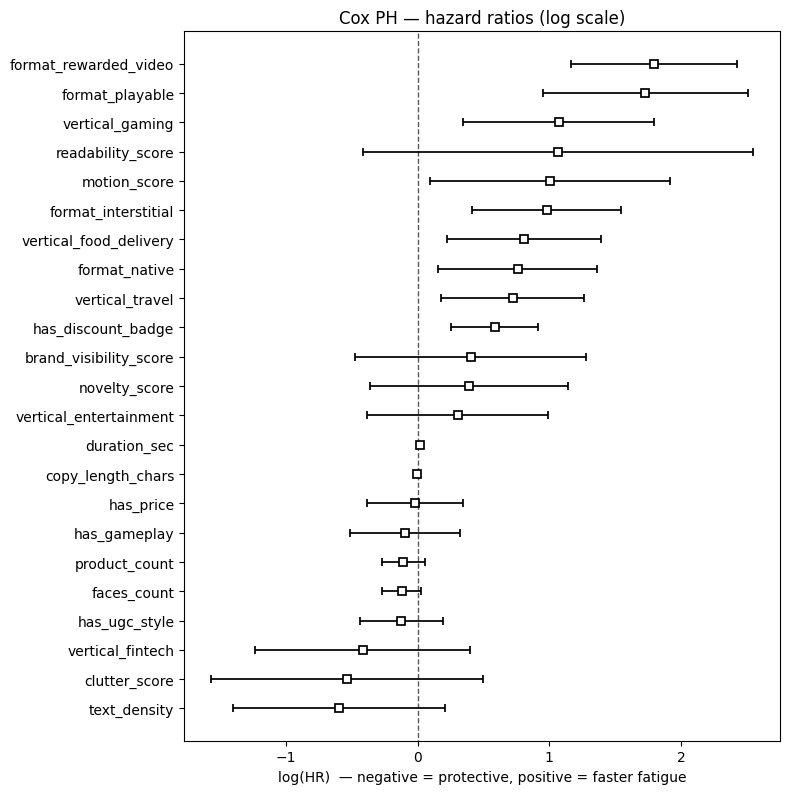

In [18]:
fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(summary))))
cph.plot(ax=ax)
ax.set_title("Cox PH — hazard ratios (log scale)")
ax.set_xlabel("log(HR)  — negative = protective, positive = faster fatigue")
plt.tight_layout()
plt.show()

## 8. Check the proportional hazards assumption

Cox assumes that the HR for each covariate is constant over time. If a covariate only matters after day 10, the assumption is violated and its estimated HR is a bad time-average.

`check_assumptions` runs Schoenfeld residual tests and flags violators. Small p-values = bad (the hazard for that covariate changes over time).

**What to do about violators**, in order of effort:
1. **Stratify** — let the violator have its own baseline hazard (usually formats or verticals).
2. **Time-interact** — fit a separate coefficient for early vs. late time bins.
3. **Switch to AFT** — parametric (Weibull) model, interpreted as multiplying lifetime rather than multiplying hazard.

In [19]:
# show_plots=False keeps the output readable; set True to see residual plots
results = cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=False)
print("\nCovariates whose PH assumption might be violated are listed above.")
print("If everything passed, move on. If not, the next cell stratifies by the main offenders.")

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'has_discount_badge' failed the non-proportional test: p-value is 0.0387.

   Advice: with so few unique values (only 2), you can include `strata=['has_discount_badge', ...]`
in the call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification


Covariates whose PH assumption might be violated are listed above.
If everything passed, move on. If not, 

## 9. Stratified Cox — let format have its own baseline hazard

Format is the most likely violator because a playable's whole fatigue curve lives on a different clock than a banner's. Stratifying means we no longer estimate an HR *for* format — we estimate everything else *within* format. The creative-feature HRs become more defensible.

In [20]:
# Rebuild the frame keeping format as a single categorical column for stratification
cox_strat = surv[structural + creative_num + creative_bin + ["duration", "event"]].copy()
cox_strat = pd.get_dummies(cox_strat, columns=["vertical"], drop_first=True, dtype=float)
# Keep 'format' as a column, do NOT dummy-encode it — strata= will handle it

cph_s = CoxPHFitter(penalizer=0.01)
cph_s.fit(cox_strat, duration_col="duration", event_col="event", strata=["format"])

summary_s = cph_s.summary[["coef", "exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
summary_s = summary_s.rename(columns={
    "exp(coef)": "HR",
    "exp(coef) lower 95%": "HR_lo",
    "exp(coef) upper 95%": "HR_hi",
}).sort_values("HR")
print(summary_s.round(3).to_string())
print(f"\nStratified concordance: {cph_s.concordance_index_:.3f}")

                         coef     HR  HR_lo   HR_hi      p
covariate                                                 
text_density           -0.564  0.569  0.254   1.277  0.172
clutter_score          -0.461  0.631  0.224   1.777  0.383
vertical_fintech       -0.395  0.674  0.297   1.528  0.345
has_ugc_style          -0.132  0.876  0.638   1.202  0.412
faces_count            -0.130  0.878  0.758   1.018  0.084
product_count          -0.106  0.899  0.764   1.058  0.201
has_gameplay           -0.084  0.920  0.605   1.398  0.695
has_price              -0.017  0.983  0.684   1.412  0.927
copy_length_chars      -0.001  0.999  0.991   1.007  0.818
duration_sec            0.010  1.010  0.989   1.033  0.352
vertical_entertainment  0.244  1.276  0.644   2.528  0.484
brand_visibility_score  0.408  1.504  0.626   3.617  0.362
novelty_score           0.425  1.529  0.718   3.255  0.271
has_discount_badge      0.584  1.792  1.291   2.489  0.000
vertical_travel         0.635  1.887  1.094   3.257  0.0

## 10. Predicted survival curves for example creatives

This is the output a creative director would actually use. Feed in a creative's metadata, get back a curve: probability of still being healthy at each future day. Pick three real creatives from the dataset — one gameplay-heavy, one discount-badge banner, one in between — and plot their predicted survival side by side.

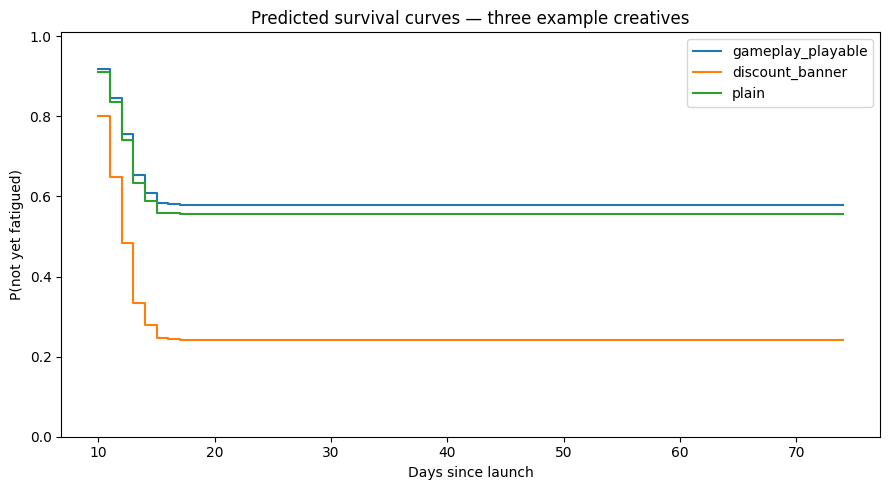

In [21]:
# Pick three representative rows from the non-stratified model's input frame
# (using non-stratified cph so we get a single unified plot; stratified would need per-stratum baselines)
examples = pd.DataFrame({
    "gameplay_playable": cox_df[
        (cox_df["has_gameplay"] == 1) & (cox_df.get("format_playable", pd.Series([0]*len(cox_df))) == 1)
    ].iloc[0] if ((cox_df["has_gameplay"] == 1) & (cox_df.get("format_playable", pd.Series([0]*len(cox_df))) == 1)).any() else cox_df[cox_df["has_gameplay"] == 1].iloc[0],
    "discount_banner": cox_df[cox_df["has_discount_badge"] == 1].iloc[0],
    "plain": cox_df[(cox_df["has_gameplay"] == 0) & (cox_df["has_discount_badge"] == 0)].iloc[0],
}).T

example_X = examples.drop(columns=["duration", "event"])

fig, ax = plt.subplots(figsize=(9, 5))
surv_preds = cph.predict_survival_function(example_X)
for col in surv_preds.columns:
    ax.step(surv_preds.index, surv_preds[col], where="post", label=col)
ax.set_xlabel("Days since launch")
ax.set_ylabel("P(not yet fatigued)")
ax.set_title("Predicted survival curves — three example creatives")
ax.legend()
ax.set_ylim(0, 1.01)
plt.tight_layout()
plt.show()

## 11. The product output — residual risk for still-running creatives

This is what turns the model from a post-mortem into a planning tool.

For every currently-running (non-fatigued) creative, compute:
- **Expected hazard** at its current `days_since_launch`, from the Cox model.
- **Survival probability remaining**: P(still healthy at its current age) — if this is much lower than 1, the model thinks this creative is 'overdue' for fatigue.

Rank creatives by *lowest predicted residual survival*. Those are the ones the advertiser should prepare replacements for *right now*.

In [22]:
still_running = surv[surv["creative_status"] != "fatigued"].copy()

# Build the same feature matrix for these rows
risk_X = still_running[feature_cols].copy()
risk_X = pd.get_dummies(risk_X, columns=structural, drop_first=True, dtype=float)
# Align columns with the training matrix (any missing dummy becomes 0)
for col in cox_df.drop(columns=["duration", "event"]).columns:
    if col not in risk_X.columns:
        risk_X[col] = 0.0
risk_X = risk_X[cox_df.drop(columns=["duration", "event"]).columns]

# Predict the survival function for each; evaluate at each creative's CURRENT age
surv_funcs = cph.predict_survival_function(risk_X)
current_ages = still_running["total_days_active"].values

def surv_at(t, col):
    # Step function: use the largest time ≤ t
    idx = surv_funcs.index[surv_funcs.index <= t]
    if len(idx) == 0:
        return 1.0
    return float(surv_funcs.loc[idx[-1], col])

still_running["pred_surv_at_current_age"] = [
    surv_at(age, col) for age, col in zip(current_ages, surv_funcs.columns)
]

# Rank the top-20 riskiest still-running creatives
riskiest = still_running.nsmallest(20, "pred_surv_at_current_age")[
    ["creative_id", "advertiser_name", "app_name", "vertical", "format",
     "total_days_active", "total_spend_usd", "pred_surv_at_current_age", "creative_status"]
]
print("Top 20 still-running creatives by lowest predicted survival at current age:\n")
print(riskiest.to_string(index=False))

Top 20 still-running creatives by lowest predicted survival at current age:

 creative_id advertiser_name           app_name      vertical         format  total_days_active  total_spend_usd  pred_surv_at_current_age creative_status
      500219      PixelForge PixelForge Legends        gaming       playable                 37         12894.05                  0.123874   top_performer
      500761       StormByte    StormByte Arena        gaming rewarded_video                 66         49375.60                  0.194752          stable
      500580      GlitchWave GlitchWave Legends        gaming rewarded_video                 39         42992.57                  0.210367          stable
      500941      VoxelRealm   VoxelRealm Quest        gaming       playable                 39         11732.04                  0.219509   top_performer
      500794      GlitchWave    GlitchWave Rush        gaming rewarded_video                 38         15789.95                  0.243357   top_per

## 12. Where to go next

- **Time-varying covariates.** Right now every feature is measured at launch and frozen. In reality, clutter doesn't change but `impressions_last_7d` does — and cumulative impressions is almost certainly the real fatigue driver. Reshape the daily table into (start, stop, event) format and fit a time-varying Cox.
- **Competing risks.** We lumped top_performer, stable, and underperformer all into "censored". A cleaner formulation treats underperformance as a competing event (Fine-Gray model) — you only fatigue if you were winning in the first place.
- **Segment-level survival.** A creative might fatigue in the US while still healthy in Mexico. Fit separate models per country, or extend to a frailty model with country as the random effect.
- **Use it as a detector.** Combine the Cox-based residual-risk score with a real-time CUSUM on daily CTR — the Cox prior tells you *which* creatives to watch closely, and the CUSUM tells you *when* to pull the trigger.